## 1.Setup and Load the Saved Features

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, roc_auc_score, average_precision_score
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

BASE = os.path.join(os.path.expanduser('~'), 'fraud-outputs')
FIG_DIR = os.path.join(BASE, 'figures')
TBL_DIR = os.path.join(BASE, 'tables')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TBL_DIR, exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, name), dpi=300, bbox_inches='tight')
    plt.show()

df = pd.read_pickle(os.path.join(BASE, 'features.pkl'))
print(df.shape)
print(df['split'].value_counts())

(1852394, 36)
split
train    1296675
test      555719
Name: count, dtype: int64


## 2. Choose the Clustering Features, take a sample, and scale

In [2]:
# Hour is circular (23:00 sits next to 00:00), so encode it as a point on a circle
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
# Log-transform heavily skewed features so outliers don't dominate the clusters
df['log_amt_vs_avg'] = np.log1p(df['amt_vs_card_avg'])
df['log_hours_since_prev'] = np.log1p(df['hours_since_prev'])

CLUSTER_FEATURES = ['log_amt', 'log_amt_vs_avg', 'hour_sin', 'hour_cos',
                    'log_hours_since_prev', 'txn_count_24h', 'age']

train_mask = df['split'] == 'train'
sample = df[train_mask].sample(n=100_000, random_state=42)

scaler = StandardScaler().fit(sample[CLUSTER_FEATURES])
X_sample = scaler.transform(sample[CLUSTER_FEATURES])
print('Clustering sample:', X_sample.shape,
      '| fraud rate in sample:', f"{sample['is_fraud'].mean()*100:.2f}%")

Clustering sample: (100000, 7) | fraud rate in sample: 0.59%


## 3. Elbow and silhouette, to choose the number of clusters

k=2: inertia=568,427  silhouette=0.176
k=3: inertia=499,786  silhouette=0.155
k=4: inertia=458,541  silhouette=0.143
k=5: inertia=423,699  silhouette=0.154
k=6: inertia=396,165  silhouette=0.156
k=7: inertia=370,721  silhouette=0.157
k=8: inertia=348,483  silhouette=0.159
k=9: inertia=330,641  silhouette=0.160


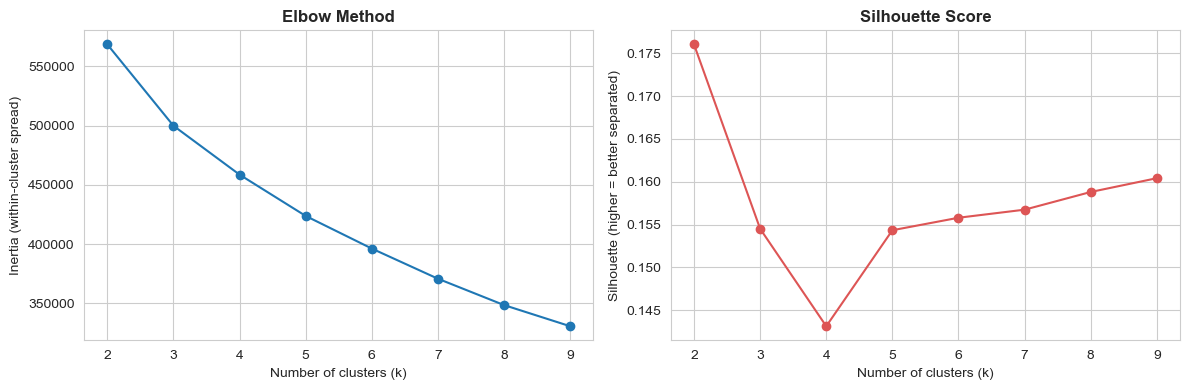

In [3]:
k_values = range(2, 10)
inertias, silhouettes = [], []
rng = np.random.default_rng(42)
sil_idx = rng.choice(len(X_sample), size=10_000, replace=False)

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_sample)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample[sil_idx], km.labels_[sil_idx]))
    print(f'k={k}: inertia={km.inertia_:,.0f}  silhouette={silhouettes[-1]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_values), inertias, marker='o')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster spread)')
axes[1].plot(list(k_values), silhouettes, marker='o', color='#DD5555')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette (higher = better separated)')
save_fig('cl_01_elbow_silhouette.png')

In [4]:
K = 5
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42).fit(X_sample)
df['cluster'] = kmeans.predict(scaler.transform(df[CLUSTER_FEATURES]))

tr = df[train_mask]
profile = tr.groupby('cluster').agg(
    transactions=('is_fraud', 'size'),
    frauds=('is_fraud', 'sum'),
    median_amt=('amt', 'median'),
    median_amt_vs_avg=('amt_vs_card_avg', 'median'),
    pct_night=('is_night', lambda s: s.mean() * 100),
    median_hours_since_prev=('hours_since_prev', 'median'),
    median_txn_24h=('txn_count_24h', 'median'),
    median_age=('age', 'median'),
    top_category=('category', lambda s: s.value_counts().index[0]))
profile['pct_of_transactions'] = profile['transactions'] / profile['transactions'].sum() * 100
profile['fraud_rate_pct'] = profile['frauds'] / profile['transactions'] * 100
profile['share_of_all_fraud_pct'] = profile['frauds'] / profile['frauds'].sum() * 100
profile = profile.round(2).sort_values('fraud_rate_pct', ascending=False)
profile.to_csv(os.path.join(TBL_DIR, 'cl_01_cluster_profiles.csv'))
profile.T

cluster,0,3,2,4,1
transactions,264188,311409,187218,276156,257704
frauds,4241,1560,555,813,337
median_amt,83.28,79.05,7.04,7.86,49.86
median_amt_vs_avg,1.21,1.15,0.11,0.12,0.68
pct_night,27.1,31.37,29.93,18.7,10.84
median_hours_since_prev,1.64,6.71,6.78,1.94,14.98
median_txn_24h,6.0,3.0,2.0,5.0,1.0
median_age,37.0,47.0,64.0,35.0,41.0
top_category,home,gas_transport,shopping_pos,shopping_pos,home
pct_of_transactions,20.37,24.02,14.44,21.3,19.87


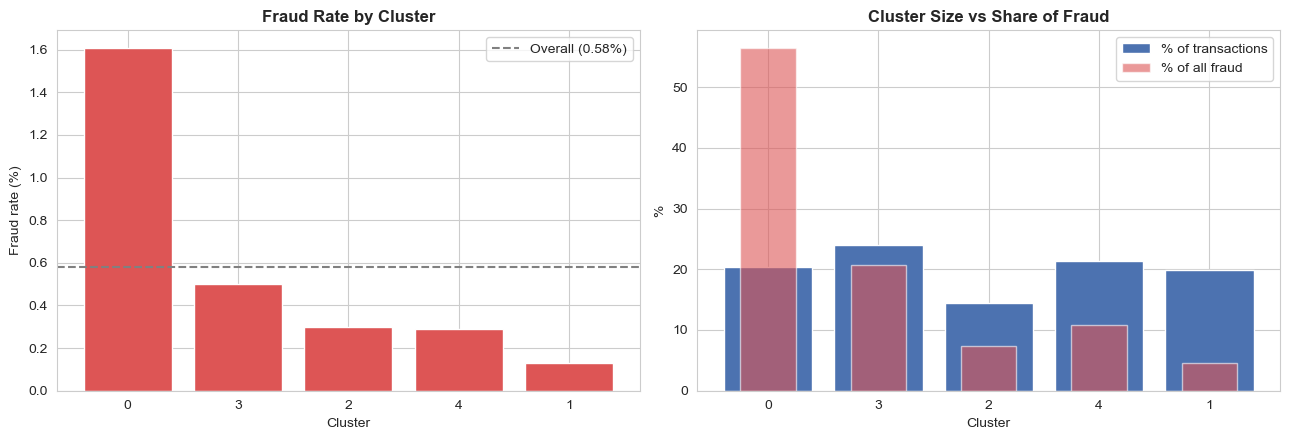

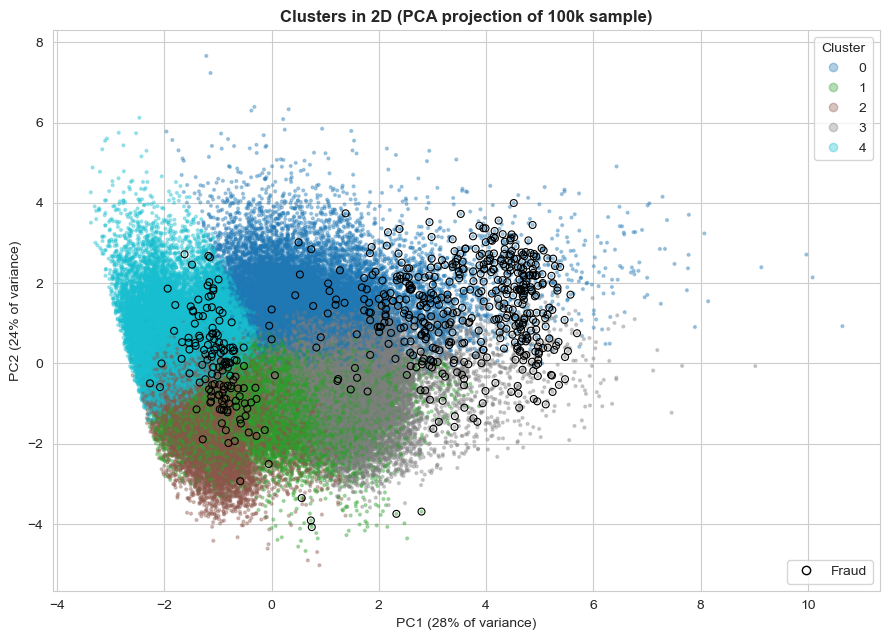

In [5]:
overall = tr['is_fraud'].mean() * 100
order = profile.index.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(order, profile['fraud_rate_pct'], color='#DD5555')
axes[0].axhline(overall, ls='--', color='grey', label=f'Overall ({overall:.2f}%)')
axes[0].set_title('Fraud Rate by Cluster', fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Fraud rate (%)')
axes[0].legend()
axes[1].bar(order, profile['pct_of_transactions'], color='#4C72B0', label='% of transactions')
axes[1].bar(order, profile['share_of_all_fraud_pct'], color='#DD5555', alpha=0.6, width=0.5,
            label='% of all fraud')
axes[1].set_title('Cluster Size vs Share of Fraud', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('%')
axes[1].legend()
save_fig('cl_02_fraud_by_cluster.png')

pca = PCA(n_components=2, random_state=42).fit(X_sample)
pts = pca.transform(X_sample)
fr = sample['is_fraud'].to_numpy() == 1

fig, ax = plt.subplots(figsize=(9, 6.5))
sc = ax.scatter(pts[:, 0], pts[:, 1], c=kmeans.labels_, cmap='tab10', s=4, alpha=0.35)
ax.scatter(pts[fr, 0], pts[fr, 1], facecolors='none', edgecolors='black', s=25, lw=0.8)
leg1 = ax.legend(*sc.legend_elements(), title='Cluster', loc='upper right')
ax.add_artist(leg1)
ax.legend(handles=[plt.Line2D([], [], marker='o', ls='', mfc='none', mec='black', label='Fraud')],
          loc='lower right')
ax.set_title('Clusters in 2D (PCA projection of 100k sample)', fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% of variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% of variance)')
save_fig('cl_03_cluster_pca.png')

In [6]:
iso = IsolationForest(n_estimators=200, contamination='auto', random_state=42, n_jobs=-1)
iso.fit(X_sample)   # learns what "normal" looks like - never sees fraud labels
df['anomaly_score'] = -iso.score_samples(scaler.transform(df[CLUSTER_FEATURES]))

te = df[df['split'] == 'test']
y, s = te['is_fraud'].to_numpy(), te['anomaly_score'].to_numpy()
print(f'Test fraud rate (random-guess baseline): {y.mean()*100:.2f}%')
print(f'ROC-AUC: {roc_auc_score(y, s):.3f}   PR-AUC: {average_precision_score(y, s):.3f}')

rows = []
order_idx = np.argsort(-s)
for pct in [0.5, 1, 2, 5, 10]:
    n = int(len(s) * pct / 100)
    top = y[order_idx[:n]]
    rows.append({'flag_top_pct': pct, 'transactions_flagged': n,
                 'frauds_caught': int(top.sum()),
                 'recall_pct': top.sum() / y.sum() * 100,
                 'precision_pct': top.mean() * 100})
iso_tbl = pd.DataFrame(rows).round(2)
iso_tbl.to_csv(os.path.join(TBL_DIR, 'cl_02_isolation_forest_test.csv'), index=False)
iso_tbl

Test fraud rate (random-guess baseline): 0.39%
ROC-AUC: 0.869   PR-AUC: 0.108


,flag_top_pct,transactions_flagged,frauds_caught,recall_pct,precision_pct
0,0.5,2778,587,27.37,21.13
1,1.0,5557,929,43.31,16.72
2,2.0,11114,1097,51.14,9.87
3,5.0,27785,1329,61.96,4.78
4,10.0,55571,1537,71.66,2.77


In [7]:
df.drop(columns=['hour_sin', 'hour_cos', 'log_amt_vs_avg', 'log_hours_since_prev']).to_pickle(
    os.path.join(BASE, 'features_v2.pkl'))
print('Saved features_v2.pkl with cluster and anomaly_score columns')

Saved features_v2.pkl with cluster and anomaly_score columns
